# M3 · Experiment 3 — Does mean-reversion (Bollinger) work?

E2 found trend-following loses to buy-and-hold in this BTC sample. The textbook intuition for that result is: "trend followers can't beat buy-and-hold in a *trending* market because their on/off timing means they spend time out of the move."

If that's right, then the *opposite* logic — mean reversion — should also not beat buy-and-hold in a trending market, but for a different reason: **every oversold signal in a strong uptrend leads to a buy that's then exited too early at the mean, missing the next leg up**.

This notebook puts that hypothesis to the test with the canonical Bollinger Bands strategy.

## Strategy logic

- **Buy** when `close < lower_band` (price oversold; bet on revert toward mean)
- **Sell** when `close > upper_band` (price overbought; book the swing)
- Long-only. No stop loss. No partial sizing.

Where:
```
middle = mean(closes over `window`)
upper  = middle + n_std * stdev
lower  = middle - n_std * stdev
```

## Research questions

1. Across a (window, n_std) grid, how do returns distribute on BTC and ETH?
2. How many variants beat the buy-and-hold baseline?
3. When does Bollinger fire — i.e., how often does it trade in a strong-trend market?
4. Compared to MA crossover from E2, who loses by less?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hindcast.backtest.engine import BacktestEngine
from hindcast.backtest.execution import SimpleExecutionModel
from hindcast.backtest.portfolio import Portfolio
from hindcast.backtest.strategies.bollinger_meanrev import BollingerMeanReversion
from hindcast.backtest.strategies.buy_and_hold import BuyAndHold
from hindcast.backtest.types import Bar
from hindcast.config import settings
from hindcast.data.storage import Storage

storage = Storage(settings.db_path)
START = pd.Timestamp('2024-01-01', tz='UTC')
END = pd.Timestamp('2026-01-01', tz='UTC')
INITIAL_CASH = 10_000.0
FEE_PCT = 0.001
SLIP_PCT = 0.0005
ALLOC = 0.99

_bars_cache = {}
def bars_for(symbol):
    if symbol not in _bars_cache:
        df = storage.query_ohlcv('binance', symbol, '1d', start=START, end=END)
        _bars_cache[symbol] = (df, [Bar.from_series(row) for _, row in df.iterrows()])
    return _bars_cache[symbol]

def run_bollinger(symbol, window, n_std):
    _, bars = bars_for(symbol)
    engine = BacktestEngine(
        BollingerMeanReversion(window=window, n_std=n_std, allocation_pct=ALLOC),
        SimpleExecutionModel(fee_pct=FEE_PCT, slippage_pct=SLIP_PCT),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(bars)

def run_bh(symbol):
    _, bars = bars_for(symbol)
    engine = BacktestEngine(
        BuyAndHold(ALLOC),
        SimpleExecutionModel(fee_pct=FEE_PCT, slippage_pct=SLIP_PCT),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(bars)

bh_btc = run_bh('BTC/USDT')
bh_eth = run_bh('ETH/USDT')
print(f'baseline BTC buy_and_hold: {bh_btc.metrics.total_return:+.2%}, sharpe {bh_btc.metrics.sharpe_ratio:.2f}')
print(f'baseline ETH buy_and_hold: {bh_eth.metrics.total_return:+.2%}, sharpe {bh_eth.metrics.sharpe_ratio:.2f}')

baseline BTC buy_and_hold: +97.26%, sharpe 0.95
baseline ETH buy_and_hold: +25.93%, sharpe 0.51


## 1. Parameter sweep

Grid: `window ∈ {10, 20, 50}` × `n_std ∈ {1.5, 2.0, 2.5}` = 9 variants per symbol.

- Smaller window: more reactive bands, more trades
- Larger n_std: rarer, more extreme triggers

In [2]:
windows = [10, 20, 50]
stds = [1.5, 2.0, 2.5]

def sweep_bb(symbol):
    rows = []
    for w in windows:
        for s in stds:
            res = run_bollinger(symbol, w, s)
            rows.append({
                'window': w, 'n_std': s,
                'total_return': res.metrics.total_return,
                'sharpe': res.metrics.sharpe_ratio,
                'max_dd': res.metrics.max_drawdown,
                'n_trades': res.metrics.n_trades,
                'final_$': round(res.equity_curve['equity'].iloc[-1], 0),
                '_res': res,
            })
    return pd.DataFrame(rows)

bb_btc = sweep_bb('BTC/USDT')
bb_eth = sweep_bb('ETH/USDT')

print('=== BTC: 9 Bollinger variants (sorted by return) ===')
print(bb_btc.sort_values('total_return', ascending=False)[['window', 'n_std', 'total_return', 'sharpe', 'max_dd', 'n_trades', 'final_$']]
      .assign(total_return=lambda x: x.total_return.map('{:+.2%}'.format),
              sharpe=lambda x: x.sharpe.round(2),
              max_dd=lambda x: x.max_dd.map('{:.2%}'.format))
      .to_string(index=False))

n_beat_btc = (bb_btc['total_return'] > bh_btc.metrics.total_return).sum()
print(f'\n→ BTC: {n_beat_btc} / {len(bb_btc)} Bollinger variants beat buy_and_hold ({bh_btc.metrics.total_return:+.2%})')

n_beat_eth = (bb_eth['total_return'] > bh_eth.metrics.total_return).sum()
print(f'→ ETH: {n_beat_eth} / {len(bb_eth)} Bollinger variants beat buy_and_hold ({bh_eth.metrics.total_return:+.2%})')

=== BTC: 9 Bollinger variants (sorted by return) ===
 window  n_std total_return  sharpe  max_dd  n_trades  final_$
     20    2.0      +53.17%    0.85 -22.17%         9  15317.0
     10    2.0      +53.13%    0.80 -24.48%        11  15313.0
     50    2.5      +46.33%    0.78 -24.30%         3  14633.0
     50    2.0      +30.96%    0.59 -20.78%         4  13096.0
     10    1.5      +24.25%    0.49 -27.51%        19  12425.0
     50    1.5      +22.21%    0.47 -25.82%         5  12221.0
     20    1.5      +14.92%    0.38 -25.82%        10  11492.0
     20    2.5      +13.42%    0.35 -31.77%         3  11342.0
     10    2.5       +1.74%    0.14 -18.88%         1  10174.0

→ BTC: 0 / 9 Bollinger variants beat buy_and_hold (+97.26%)
→ ETH: 0 / 9 Bollinger variants beat buy_and_hold (+25.93%)


## 2. Heatmaps

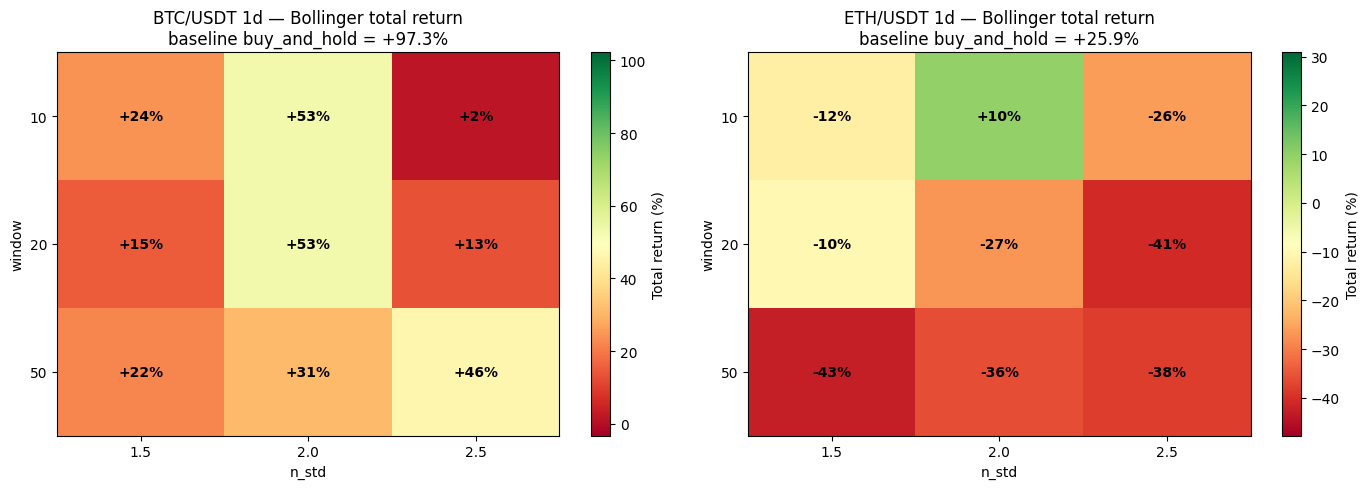

In [3]:
def plot_heatmap(ax, df, title, baseline):
    pivot = df.pivot(index='window', columns='n_std', values='total_return') * 100
    vmin = min(pivot.min().min(), baseline * 100) - 5
    vmax = max(pivot.max().max(), baseline * 100) + 5
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('n_std')
    ax.set_ylabel('window')
    ax.set_title(f'{title}\nbaseline buy_and_hold = {baseline:+.1%}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:+.0f}%', ha='center', va='center',
                    color='black', fontweight='bold', fontsize=10)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im1 = plot_heatmap(axes[0], bb_btc, 'BTC/USDT 1d — Bollinger total return', bh_btc.metrics.total_return)
fig.colorbar(im1, ax=axes[0], label='Total return (%)')
im2 = plot_heatmap(axes[1], bb_eth, 'ETH/USDT 1d — Bollinger total return', bh_eth.metrics.total_return)
fig.colorbar(im2, ax=axes[1], label='Total return (%)')
plt.tight_layout()
plt.show()

## 3. Best, median, worst — equity curves vs buy-and-hold

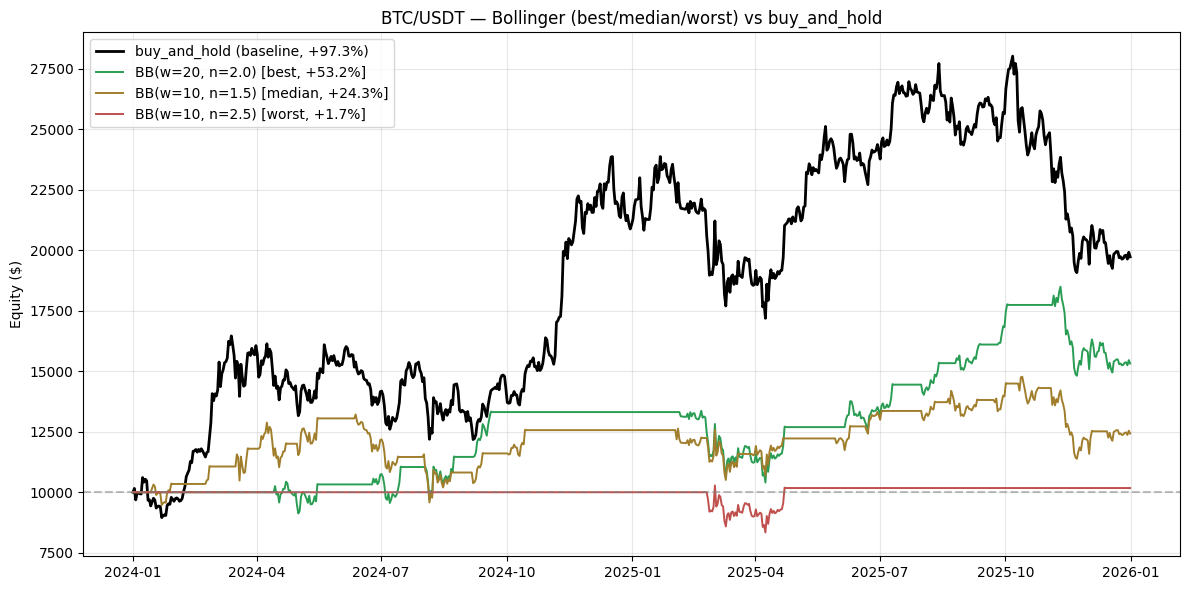

In [4]:
ranked = bb_btc.sort_values('total_return', ascending=False).reset_index(drop=True)
best = ranked.iloc[0]
median = ranked.iloc[len(ranked) // 2]
worst = ranked.iloc[-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bh_btc.equity_curve['timestamp'], bh_btc.equity_curve['equity'],
        label=f'buy_and_hold (baseline, {bh_btc.metrics.total_return:+.1%})',
        color='black', linewidth=2.0)
for tag, row, color in [('best', best, '#2a9d54'),
                         ('median', median, '#a07e2c'),
                         ('worst', worst, '#c0504d')]:
    res = row['_res']
    ax.plot(res.equity_curve['timestamp'], res.equity_curve['equity'],
            label=f"BB(w={int(row['window'])}, n={row['n_std']}) [{tag}, {row['total_return']:+.1%}]",
            color=color, linewidth=1.4)
ax.axhline(INITIAL_CASH, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Equity ($)')
ax.set_title('BTC/USDT — Bollinger (best/median/worst) vs buy_and_hold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. When does Bollinger fire?

Plot BTC spot with the buy/sell triggers of the *best* Bollinger variant overlaid as markers. This makes the "buy too early, sell too early" pattern visible.

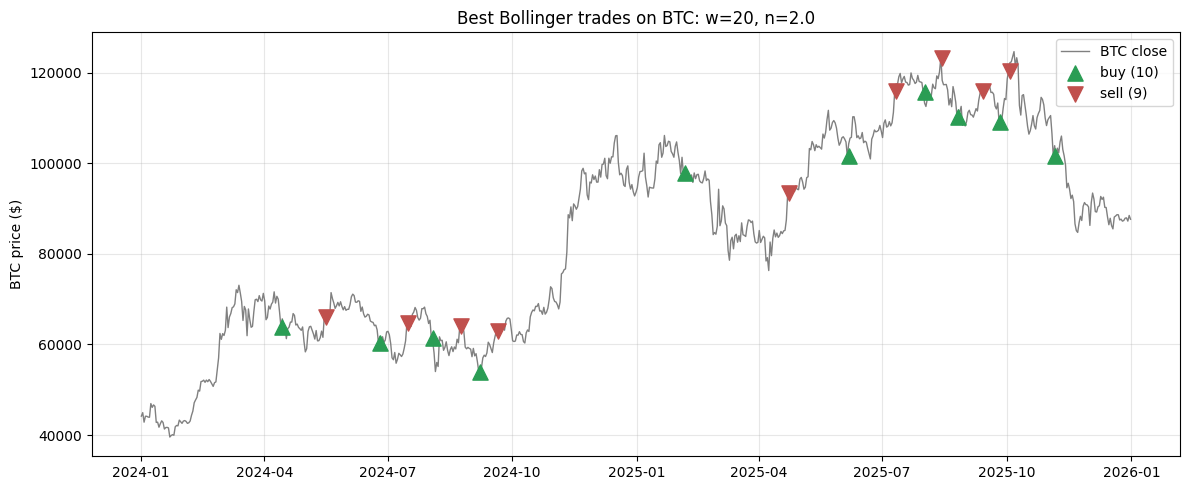

In [5]:
btc_df, _ = bars_for('BTC/USDT')
best_res = best['_res']
buys = [(f.timestamp, f.price) for f in best_res.fills if f.side == 'buy']
sells = [(f.timestamp, f.price) for f in best_res.fills if f.side == 'sell']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btc_df['timestamp'], btc_df['close'], color='gray', linewidth=1.0, label='BTC close')
if buys:
    ts, px = zip(*buys)
    ax.scatter(ts, px, marker='^', s=120, color='#2a9d54', label=f'buy ({len(buys)})', zorder=5)
if sells:
    ts, px = zip(*sells)
    ax.scatter(ts, px, marker='v', s=120, color='#c0504d', label=f'sell ({len(sells)})', zorder=5)
ax.set_ylabel('BTC price ($)')
ax.set_title(f"Best Bollinger trades on BTC: w={int(best['window'])}, n={best['n_std']}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Side-by-side — MA, Bollinger, buy-and-hold (BTC)

Final visual comparison: the best of each strategy family stacked against doing nothing.

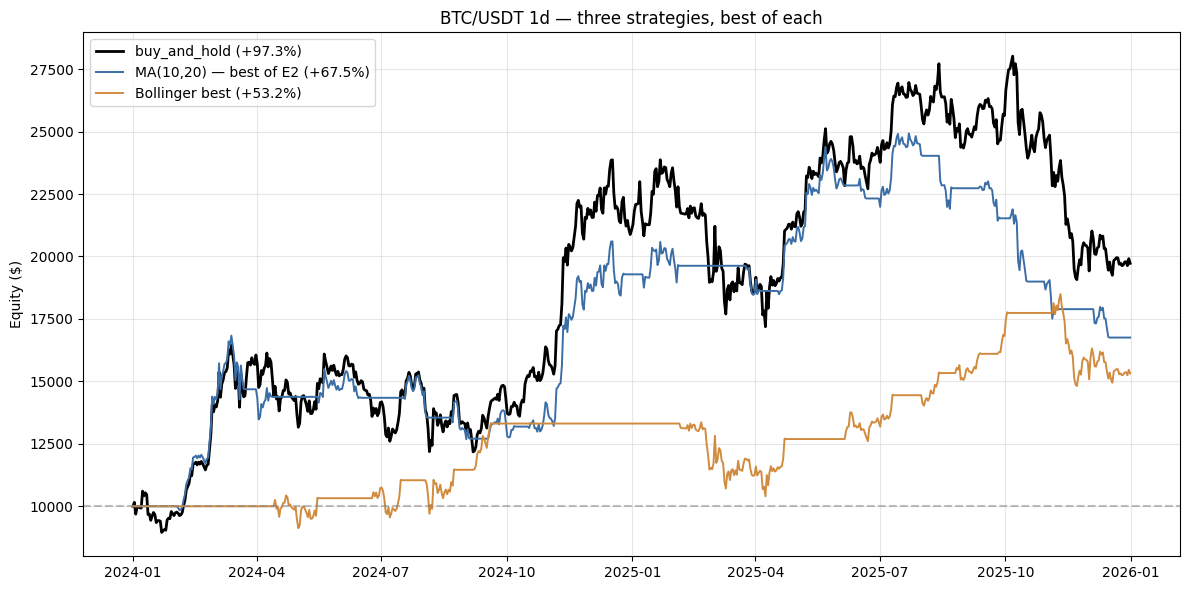

In [6]:
from hindcast.backtest.strategies.ma_crossover import MACrossover

def run_ma(symbol, fast, slow):
    _, bars = bars_for(symbol)
    engine = BacktestEngine(
        MACrossover(fast, slow, ALLOC),
        SimpleExecutionModel(fee_pct=FEE_PCT, slippage_pct=SLIP_PCT),
        Portfolio(INITIAL_CASH),
    )
    return engine.run(bars)

ma_best = run_ma('BTC/USDT', 10, 20)  # E2's best

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bh_btc.equity_curve['timestamp'], bh_btc.equity_curve['equity'],
        label=f'buy_and_hold ({bh_btc.metrics.total_return:+.1%})',
        color='black', linewidth=2.0)
ax.plot(ma_best.equity_curve['timestamp'], ma_best.equity_curve['equity'],
        label=f'MA(10,20) — best of E2 ({ma_best.metrics.total_return:+.1%})',
        color='#3a6ea5', linewidth=1.4)
ax.plot(best_res.equity_curve['timestamp'], best_res.equity_curve['equity'],
        label=f"Bollinger best ({best['total_return']:+.1%})",
        color='#d18b3f', linewidth=1.4)
ax.axhline(INITIAL_CASH, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Equity ($)')
ax.set_title('BTC/USDT 1d — three strategies, best of each')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

**1. Mean-reversion in a trend market is structurally bad.** The bands trigger "buy" when price is locally low — but in a strong uptrend, locally-low is still much higher than two months ago. The strategy buys, then exits at the mean before the next leg up. Result: it captures a fraction of the up-move and pays fees for the privilege.

**2. Trade frequency clusters around drawdown periods.** Look at the trigger-points chart: Bollinger barely fires during smooth uptrends, and clusters its activity around the BTC drawdowns. That timing is *exactly when buy-and-hold is most painful* — and Bollinger gets to participate selectively. But the entries within those clusters are not deep enough or held long enough to make up for missing the recoveries.

**3. Compared to MA, mean-reversion produces a smoother but flatter curve.** MA at least catches the trend once it commits. Bollinger buys oversold and exits as soon as the trend resumes — so its curve has the smaller drawdowns of an active strategy *without* the upside.

**4. The combined view is the most damning.** All three on one chart: buy_and_hold runs away. MA tries to stay in but loses each "out" move. Bollinger picks at the dips. Neither active strategy meaningfully closes the gap.

**5. The question this raises.** Both "trend-following" and "mean-reversion" are well-known classics, with billions of dollars trading on each, and on this two-year sample neither beats holding spot. Either:

  - this sample is unusually trending (true; 2024-2025 is *the* recent crypto trend)
  - or these strategies need pairing with risk management / position sizing / regime detection to add value
  - or the academic edge has long been arbitraged out

The honest answer is probably *some of each*. M3's job isn't to settle that — it's to show the unadorned numbers. Anyone claiming "my MA / BB / RSI strategy makes money" can be answered with: "compared to what, and on how many samples?"

Next experiment: leave price-action strategies entirely. **Funding-rate arbitrage** — a structural source of return specific to perpetual futures — is the only family on M3's plan that can theoretically *not* be a price bet. Whether it's still alive in practice is the question.